In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 38.9 MB/s eta 0:00:00


In [4]:
!pip install torch-scatter torch-sparse torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cpu.html

Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.0/494.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.2 MB/s eta 0:00:00


In [5]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser
from scipy.spatial.distance import pdist, squareform
import torch
from torch_geometric.data import Data
import pickle

/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_scatter/_version_cpu.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_sparse/_version_cpu.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [32]:
#Convert 3-letter amino acid codes to 1-letter codes

three_to_one = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D',
    'CYS': 'C', 'GLN': 'Q', 'GLU': 'E', 'GLY': 'G',
    'HIS': 'H', 'ILE': 'I', 'LEU': 'L', 'LYS': 'K',
    'MET': 'M', 'PHE': 'F', 'PRO': 'P', 'SER': 'S',
    'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V',
    'SEC': 'U', 'PYL': 'O', 'ASX': 'B', 'GLX': 'Z', 'XLE': 'J', 'UNK': 'X'
}


In [33]:
# Load amino acid properties from a CSV file into a dictionary

def load_amino_acid_properties(csv_path):
    df = pd.read_csv(csv_path)
    properties = {}
    for _, row in df.iterrows():
        aa = row['AA']
        properties[aa] = {
            'hydrophobicity': row['Hydrophobicity'],
            'molecular_weight': row['MolecularWeight'],
            'charge': row['Charge']
        }
    return properties

In [34]:
#Extract Cα coordinates and full amino acid sequence from all chains in a PDB file

def extract_ca_coords_and_sequence_all_chains(pdb_path):
    try:
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure("protein", pdb_path)
        model = structure[0]

        coords = []
        sequence = ""
        for chain in model:
            for residue in chain:
                if 'CA' in residue:
                    ca = residue['CA'].get_coord()
                    coords.append(ca)
                    resname = residue.get_resname()
                    aa = three_to_one.get(resname, 'X')
                    sequence += aa

        return np.array(coords), sequence

    except Exception as e:
        print("Error reading PDB:", e)
        return None, None

In [35]:
#Build a graph with spatial and sequential edges based on residue coordinates and properties

def build_spatial_and_sequence_graph(sequence, coords, feature_dict, distance_threshold=8.0):
    G = nx.Graph()

    for i, aa in enumerate(sequence):
        features = feature_dict.get(aa, {'hydrophobicity': 0, 'molecular_weight': 0, 'charge': 0})
        G.add_node(i, aa=aa, **features)

    dist_matrix = squareform(pdist(coords))

    for i in range(len(sequence)):
        for j in range(i + 1, len(sequence)):
            d = dist_matrix[i, j]
            if d <= distance_threshold:
                G.add_edge(i, j, weight=d)

    # add sequential edges
    for i in range(len(sequence) - 1):
        G.add_edge(i, i + 1, weight=1.0)

    return G

In [42]:
#Create an undirected protein graph with spatial edges and single sequential edges between neighboring residues

def build_spatial_and_sequence_graph(sequence, coords, feature_dict, distance_threshold=8.0):
    G = nx.Graph()

    for i, aa in enumerate(sequence):
        features = feature_dict.get(aa, {'hydrophobicity': 0, 'molecular_weight': 0, 'charge': 0})
        G.add_node(i, aa=aa, **features)

    dist_matrix = squareform(pdist(coords))

    for i in range(len(sequence)):
        for j in range(i + 1, len(sequence)):
            d = dist_matrix[i, j]
            if d <= distance_threshold:
                G.add_edge(i, j, weight=d)

    # We only add one edge between each pair of neighboring residues (because the NetworkX graph is undirected).
    for i in range(len(sequence) - 1):
        G.add_edge(i, i + 1, weight=1.0)

    return G

In [37]:
#Convert a NetworkX graph to a PyTorch Geometric graph with bidirectional edges and node features

def convert_nx_to_pyg(graph):
    edge_index = []
    for i, j in graph.edges:
        edge_index.append([i, j])
        edge_index.append([j, i])  #For PyG, you need to clearly add edges in both directions.

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    features = []
    for _, data in graph.nodes(data=True):
        features.append([
            data.get('hydrophobicity', 0),
            data.get('molecular_weight', 0),
            data.get('charge', 0)
        ])
    x = torch.tensor(features, dtype=torch.float)
    return Data(x=x, edge_index=edge_index)

In [54]:
#Save Graph as GraphML and binary using pickle

def save_graph(graph, path_prefix="/content/drive/MyDrive/GitHub/ProtGraphX/graphs/protein_graph"):
    try:
        # Save as GraphML (for visualization tools)
        nx.write_graphml(graph, f"{path_prefix}.graphml")

        # Save as binary using pickle
        with open(f"{path_prefix}.gpickle", "wb") as f:
            pickle.dump(graph, f)

        print(f"Graph saved successfully at: {path_prefix}.graphml and .gpickle")
    except Exception as e:
        print("⚠️ Failed to save the graph:", e)


In [28]:
#Visualize and save a protein graph as an image colored by hydrophobicity

def save_graph_image(G, filename="/content/drive/MyDrive/GitHub/ProtGraphX/graph.png"):
    pos = nx.spring_layout(G, seed=42)
    hydros = [G.nodes[n]['hydrophobicity'] for n in G.nodes]

    plt.figure(figsize=(12, 8))
    nodes = nx.draw_networkx_nodes(G, pos, node_color=hydros, cmap='coolwarm', node_size=100)
    nx.draw_networkx_edges(G, pos, alpha=0.3)
    plt.colorbar(nodes, label='Hydrophobicity')
    plt.title("Spatial + Sequence Graph - Hydrophobicity")
    plt.axis('off')
    plt.savefig(filename, dpi=300)
    plt.close()

In [23]:
#Display a protein graph colored by hydrophobicity using NetworkX and Matplotlib

def show_graph_by_hydrophobicity(G, title="Spatial + Sequence Graph - Hydrophobicity"):
    pos = nx.spring_layout(G, seed=42)
    hydros = [G.nodes[n]['hydrophobicity'] for n in G.nodes]

    plt.figure(figsize=(12, 8))
    nodes = nx.draw_networkx_nodes(G, pos, node_color=hydros, cmap='coolwarm', node_size=100)
    nx.draw_networkx_edges(G, pos, alpha=0.3)
    plt.colorbar(nodes, label='Hydrophobicity')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [56]:
# Paths

pdb_path = "/content/drive/MyDrive/GitHub/ProtGraphX/data/1AOS.pdb"
csv_path = "/content/drive/MyDrive/GitHub/ProtGraphX/data/Amino_Acid_Properties.csv"

aac_properties = load_amino_acid_properties(csv_path)
coords, sequence = extract_ca_coords_and_sequence_all_chains(pdb_path)
graph = build_spatial_and_sequence_graph(sequence, coords, aac_properties, distance_threshold=8.0)
save_graph(graph)

Graph saved successfully at: /content/drive/MyDrive/GitHub/ProtGraphX/graphs/protein_graph.graphml and .gpickle


Nodes: 868
Edges: 4192


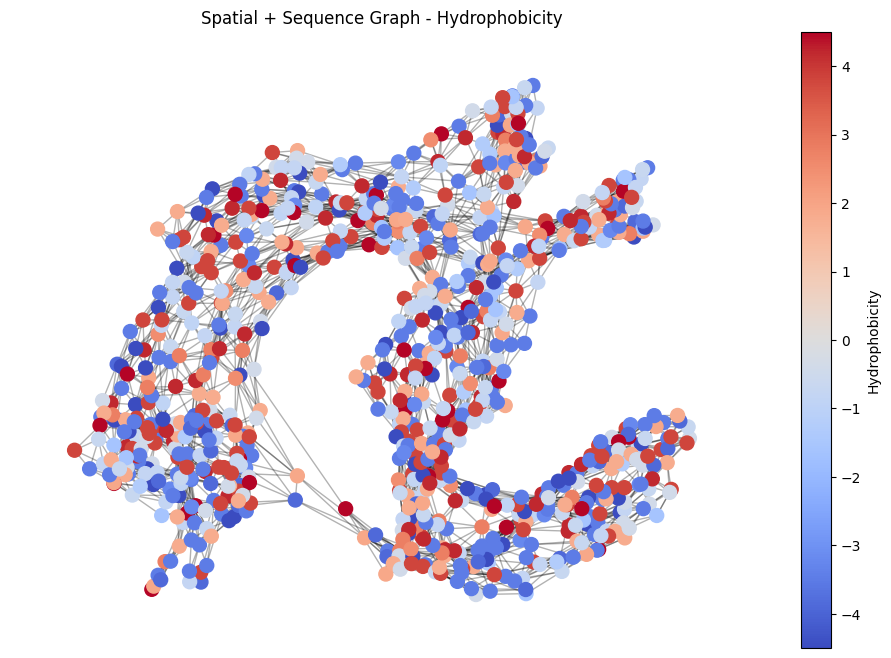

In [57]:
# Visualize and Save
print("Nodes:", graph.number_of_nodes())
print("Edges:", graph.number_of_edges())
show_graph_by_hydrophobicity(graph)
save_graph_image(graph)

In [17]:
# Convert to PyG and save
pyg_graph = convert_nx_to_pyg(graph)
torch.save(pyg_graph, "/content/drive/MyDrive/GitHub/ProtGraphX/graphs/1AOS_graph.pt")
print("PyG graph saved.")


PyG graph saved.
